In [ ]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.5 MB/s eta 0:00:00


Using device: cpu


Extracting qm9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Train size: 100000
Validation size: 10000
Test size: 20831

Training Mean: 2.672952651977539
Training Std: 1.5034793615341187


/tmp/ipykernel_3934/2074470985.py:73: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  train_y = train_dataset.data.y[:, target]
/tmp/ipykernel_3934/2074470985.py:84: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppres


Epoch 1
Train Loss: 0.291600
Val RMSE: 0.871284
Val MAE: 0.732578
Val R²: -0.762103
Best model saved.

Epoch 2
Train Loss: 0.183994
Val RMSE: 0.481286
Val MAE: 0.360955
Val R²: 0.462327
Best model saved.

Epoch 3
Train Loss: 0.144580
Val RMSE: 0.486434
Val MAE: 0.374450
Val R²: 0.450763

Epoch 4
Train Loss: 0.119078
Val RMSE: 0.451127
Val MAE: 0.345897
Val R²: 0.527600
Best model saved.

Epoch 5
Train Loss: 0.099821
Val RMSE: 0.408146
Val MAE: 0.308848
Val R²: 0.613328
Best model saved.

Epoch 6
Train Loss: 0.087261
Val RMSE: 0.445663
Val MAE: 0.349922
Val R²: 0.538974

Epoch 7
Train Loss: 0.080569
Val RMSE: 0.392278
Val MAE: 0.293786
Val R²: 0.642810
Best model saved.

Epoch 8
Train Loss: 0.074310
Val RMSE: 0.381595
Val MAE: 0.286238
Val R²: 0.662000
Best model saved.

Epoch 9
Train Loss: 0.070498
Val RMSE: 0.379245
Val MAE: 0.282731
Val R²: 0.666149
Best model saved.

Epoch 10
Train Loss: 0.067956
Val RMSE: 0.387107
Val MAE: 0.289840
Val R²: 0.652165

Epoch 11
Train Loss: 0.066311
V

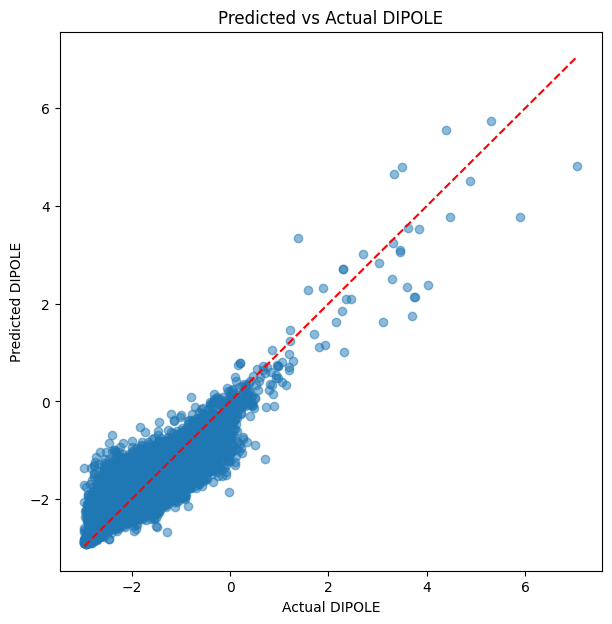

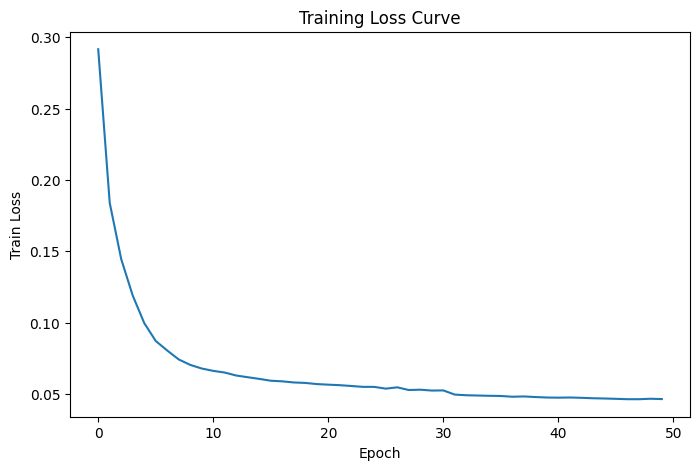


SAMPLE PREDICTIONS
Actual: -0.980903 | Predicted: -1.282277
Actual: -1.619802 | Predicted: -1.810071
Actual: -1.546852 | Predicted: -2.094776
Actual: -1.621041 | Predicted: -2.090721
Actual: -1.149719 | Predicted: -1.058620
Actual: -1.736283 | Predicted: -1.400301
Actual: -2.276618 | Predicted: -2.373527
Actual: -2.274008 | Predicted: -2.184287
Actual: -0.398850 | Predicted: -0.497200
Actual: -2.272371 | Predicted: -2.204539


In [ ]:

# DIPOLE PROPERTY PREDICTION USING GIN

import os
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch.nn import Linear, Sequential, ReLU, BatchNorm1d, Dropout
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

# REPRODUCIBILITY

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# LOAD DATASET

path = "./qm9"
dataset = QM9(path)

# DIPOLE TARGET INDEX
# QM9 target index for DIPOLE = 0
target = 0

# SHUFFLE DATASET

dataset = dataset.shuffle()

# TRAIN / VAL / TEST SPLIT

train_dataset = dataset[:100000]
val_dataset = dataset[100000:110000]
test_dataset = dataset[110000:]

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# NORMALIZATION (ONLY USING TRAIN DATA)

train_y = train_dataset.data.y[:, target]

mean = train_y.mean().item()
std = train_y.std().item()

print(f"\nTraining Mean: {mean}")
print(f"Training Std: {std}")

# Normalize datasets
for split in [train_dataset, val_dataset, test_dataset]:
    split.data.y[:, target] = (
        split.data.y[:, target] - mean
    ) / std


# DATALOADERS

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# GIN MODEL

class GINNet(torch.nn.Module):

    def __init__(self, num_features):

        super(GINNet, self).__init__()

        hidden_dim = 64

        # GIN Layer 1

        nn1 = Sequential(
            Linear(num_features, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.bn1 = BatchNorm1d(hidden_dim)

        # GIN Layer 2

        nn2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv2 = GINConv(nn2)
        self.bn2 = BatchNorm1d(hidden_dim)

        # GIN Layer 3

        nn3 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv3 = GINConv(nn3)
        self.bn3 = BatchNorm1d(hidden_dim)

        # REGRESSION HEAD
        self.lin1 = Linear(hidden_dim, 64)
        self.dropout = Dropout(0.2)
        self.lin2 = Linear(64, 1)

    def forward(self, data):

        x = data.x.float()
        edge_index = data.edge_index
        batch = data.batch

        # GIN Layers

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # GLOBAL POOLING

        x = global_add_pool(x, batch)

        # REGRESSION HEAD

        x = self.lin1(x)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.lin2(x)

        return x.squeeze()

# MODEL INITIALIZATION

model = GINNet(dataset.num_features).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

criterion = torch.nn.MSELoss()

# TRAIN FUNCTION

def train():

    model.train()

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        pred = model(data)

        target_y = data.y[:, target]

        loss = criterion(pred, target_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)

# EVALUATION FUNCTION

def evaluate(loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for data in loader:

            data = data.to(device)

            pred = model(data)

            preds.append(pred.cpu())
            targets.append(data.y[:, target].cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    # INVERSE NORMALIZATION

    preds_denorm = preds * std + mean
    targets_denorm = targets * std + mean

    rmse = np.sqrt(
        mean_squared_error(targets_denorm, preds_denorm)
    )

    mae = mean_absolute_error(
        targets_denorm,
        preds_denorm
    )

    r2 = r2_score(
        targets_denorm,
        preds_denorm
    )

    return rmse, mae, r2, preds_denorm, targets_denorm

# TRAINING LOOP

best_val_rmse = float("inf")

train_losses = []
val_rmses = []

epochs = 50

for epoch in range(1, epochs + 1):

    train_loss = train()

    val_rmse, val_mae, val_r2, _, _ = evaluate(val_loader)

    scheduler.step(val_rmse)

    train_losses.append(train_loss)
    val_rmses.append(val_rmse)

    print(f"\nEpoch {epoch}")

    print(f"Train Loss: {train_loss:.6f}")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val MAE: {val_mae:.6f}")
    print(f"Val R²: {val_r2:.6f}")

    # SAVE BEST MODEL

    if val_rmse < best_val_rmse:

        best_val_rmse = val_rmse

        torch.save(
            model.state_dict(),
            "best_dipole_model.pth"
        )

        print("Best model saved.")

# LOAD BEST MODEL

model.load_state_dict(
    torch.load("best_dipole_model.pth")
)
# FINAL TEST EVALUATION

test_rmse, test_mae, test_r2, preds, targets = evaluate(test_loader)

print("\n================================================")
print("FINAL TEST RESULTS")
print("================================================")

print(f"Test RMSE : {test_rmse:.6f}")
print(f"Test MAE  : {test_mae:.6f}")
print(f"Test R²   : {test_r2:.6f}")

# PREDICTED VS ACTUAL PLOT

plt.figure(figsize=(7, 7))

plt.scatter(
    targets,
    preds,
    alpha=0.5
)

min_val = min(targets.min(), preds.min())
max_val = max(targets.max(), preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual DIPOLE")
plt.ylabel("Predicted DIPOLE")

plt.title("Predicted vs Actual DIPOLE")

plt.show()

# LOSS CURVE

plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")

plt.title("Training Loss Curve")

plt.show()

# SAMPLE PREDICTIONS

print("\n================================================")
print("SAMPLE PREDICTIONS")
print("================================================")

for i in range(10):

    print(
        f"Actual: {targets[i]:.6f} | "
        f"Predicted: {preds[i]:.6f}"
    )

In [ ]:
import torch
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from torch.nn import (
    Linear,
    Sequential,
    ReLU,
    BatchNorm1d,
    Dropout
)

from torch_geometric.nn import (
    GINConv,
    global_add_pool
)



Embedding Shape: (20831, 64)


PermutationExplainer explainer: 301it [00:15, 11.69it/s]                         
/tmp/ipykernel_3934/2833522575.py:226: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


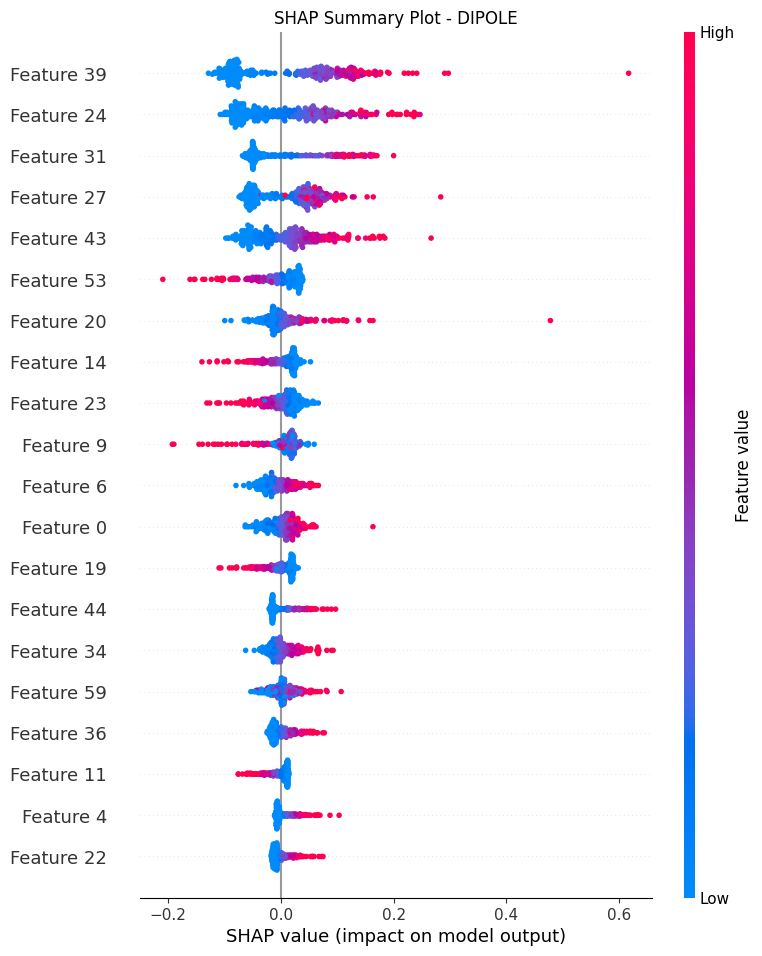

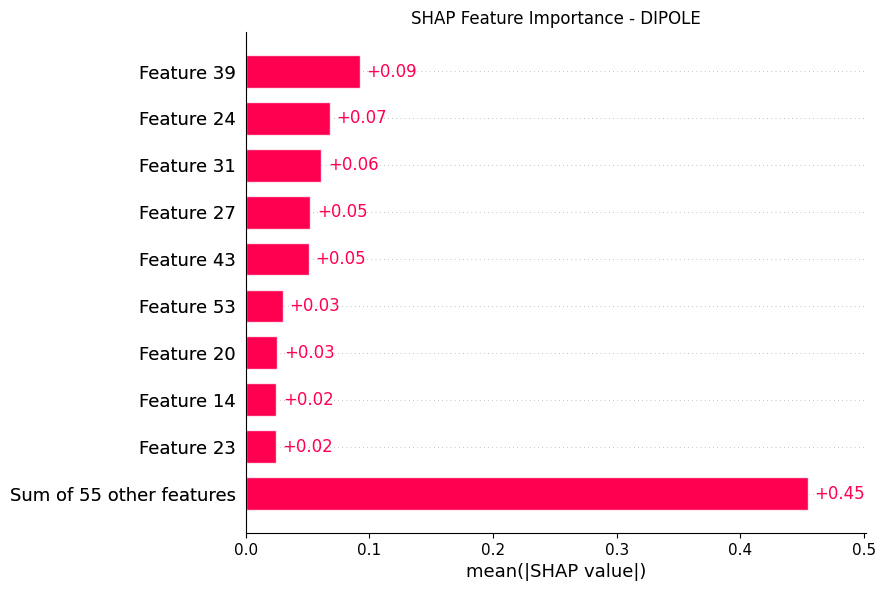


TOP IMPORTANT EMBEDDING FEATURES
    Embedding Dimension  Mean SHAP Value
39                   39         0.092492
24                   24         0.068038
31                   31         0.061092
27                   27         0.052296
43                   43         0.050776
53                   53         0.029825
20                   20         0.025449
14                   14         0.024654
23                   23         0.024257
9                     9         0.022474


In [ ]:

# SHAP ANALYSIS FOR GIN MODEL
# (Graph Embedding Explainability)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#  MODIFY MODEL TO RETURN EMBEDDINGS


class GINNet(torch.nn.Module):

    def __init__(self, num_features):

        super(GINNet, self).__init__()

        hidden_dim = 64

        # GIN Layer 1

        nn1 = Sequential(
            Linear(num_features, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(nn1)
        self.bn1 = BatchNorm1d(hidden_dim)

        # GIN Layer 2

        nn2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv2 = GINConv(nn2)
        self.bn2 = BatchNorm1d(hidden_dim)

        # GIN Layer 3

        nn3 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )

        self.conv3 = GINConv(nn3)
        self.bn3 = BatchNorm1d(hidden_dim)

        # REGRESSION HEAD

        self.lin1 = Linear(hidden_dim, 64)

        self.dropout = Dropout(0.2)

        self.lin2 = Linear(64, 1)


    def forward(self, data, return_embedding=False):

        x = data.x.float()

        edge_index = data.edge_index

        batch = data.batch

        # GIN layers

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        # GRAPH EMBEDDING

        embedding = global_add_pool(x, batch)

        # Regression Head

        out = self.lin1(embedding)

        out = F.relu(out)

        out = self.dropout(out)

        out = self.lin2(out)

        if return_embedding:
            return out.squeeze(), embedding

        return out.squeeze()

#  RELOAD TRAINED MODEL

model = GINNet(dataset.num_features).to(device)

model.load_state_dict(
    torch.load("best_dipole_model.pth")
)

model.eval()

#  EXTRACT EMBEDDINGS

embeddings = []
targets = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        pred, emb = model(
            data,
            return_embedding=True
        )

        embeddings.append(emb.cpu().numpy())

        targets.append(
            data.y[:, target].cpu().numpy()
        )

X_embeddings = np.concatenate(embeddings, axis=0)

y_targets = np.concatenate(targets, axis=0)

print("Embedding Shape:", X_embeddings.shape)

# CREATE REGRESSION HEAD WRAPPER

class RegressionHead(torch.nn.Module):

    def __init__(self, lin1, dropout, lin2):

        super().__init__()

        self.lin1 = lin1
        self.dropout = dropout
        self.lin2 = lin2

    def forward(self, x):

        x = torch.tensor(
            x,
            dtype=torch.float32
        ).to(device)

        x = self.lin1(x)

        x = F.relu(x)

        x = self.dropout(x)

        x = self.lin2(x)

        return x.detach().cpu().numpy()

# SHAP EXPLAINER

reg_head = RegressionHead(
    model.lin1,
    model.dropout,
    model.lin2
)

# Smaller subset for speed
background = X_embeddings[:200]

sample_data = X_embeddings[200:500]

explainer = shap.Explainer(
    reg_head,
    background
)

shap_values = explainer(sample_data)

#  SHAP SUMMARY PLOT

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    sample_data,
    show=False
)

plt.title("SHAP Summary Plot - DIPOLE")

plt.show()

#  SHAP BAR PLOT

plt.figure(figsize=(10, 6))

shap.plots.bar(
    shap_values,
    show=False
)

plt.title("SHAP Feature Importance - DIPOLE")

plt.show()

# FEATURE IMPORTANCE TABLE

mean_shap = np.abs(
    shap_values.values
).mean(axis=0)

feature_importance = pd.DataFrame({

    "Embedding Dimension":
    np.arange(len(mean_shap)),

    "Mean SHAP Value":
    mean_shap

})

feature_importance = feature_importance.sort_values(
    by="Mean SHAP Value",
    ascending=False
)

print("\n================================================")
print("TOP IMPORTANT EMBEDDING FEATURES")
print("================================================")

print(feature_importance.head(10))

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7016a3021abe4e85f97c755e517bfe9178edf66cc05c74b535a72dca458981fe
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

Embedding shape: (20831, 64)
Actual DIPOLE: -2.3443918
Predicted DIPOLE: -2.272678


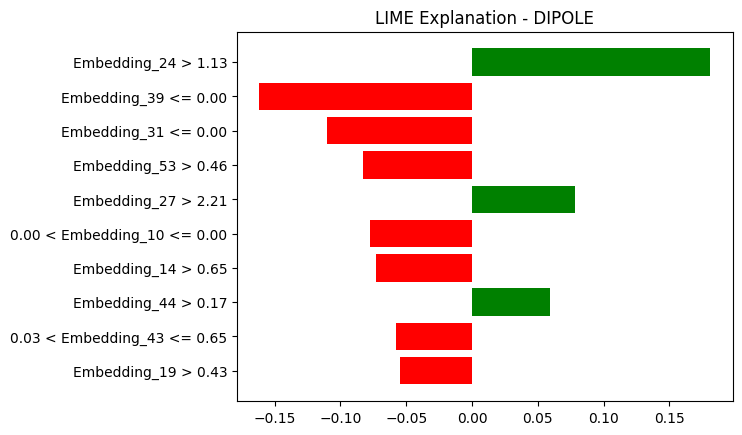


Top LIME Features:
Embedding_24 > 1.13 : 0.18118921820418335
Embedding_39 <= 0.00 : -0.16166970273481782
Embedding_31 <= 0.00 : -0.11040653387823172
Embedding_53 > 0.46 : -0.0829173425679218
Embedding_27 > 2.21 : 0.07837960113702935
0.00 < Embedding_10 <= 0.00 : -0.07725738117459875
Embedding_14 > 0.65 : -0.07312106307476901
Embedding_44 > 0.17 : 0.05922219385637602
0.03 < Embedding_43 <= 0.65 : -0.057516464027856956
Embedding_19 > 0.43 : -0.05506897651088887


In [ ]:

# LIME FOR GNN EMBEDDING INTERPRETATION

import lime
import lime.lime_tabular
import numpy as np
import torch
import torch.nn.functional as F

# EXTRACT TEST EMBEDDINGS

model.eval()

embeddings = []
targets = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        pred, emb = model(
            data,
            return_embedding=True
        )

        embeddings.append(
            emb.cpu().numpy()
        )

        targets.append(
            data.y[:, target].cpu().numpy()
        )

X_embeddings = np.concatenate(embeddings, axis=0)
y_targets = np.concatenate(targets, axis=0)

print("Embedding shape:", X_embeddings.shape)

# REGRESSION HEAD WRAPPER (NO DROPOUT)

class RegressionHead:

    def __init__(self, lin1, lin2):

        self.lin1 = lin1
        self.lin2 = lin2

    def predict(self, x):

        x = torch.tensor(
            x,
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():

            x = self.lin1(x)

            x = F.relu(x)

            x = self.lin2(x)

        return x.cpu().numpy()

reg_head = RegressionHead(
    model.lin1,
    model.lin2
)

# CREATE LIME EXPLAINER

feature_names = [
    f"Embedding_{i}"
    for i in range(X_embeddings.shape[1])
]

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_embeddings,
    feature_names=feature_names,
    mode='regression'
)

# PICK ONE TEST MOLECULE

sample_index = 10

sample = X_embeddings[sample_index]

actual_normalized = y_targets[sample_index]

actual_denorm = actual_normalized * std + mean

print("Actual DIPOLE:", actual_denorm)

prediction = reg_head.predict(
    sample.reshape(1, -1)
)

pred_denorm = prediction[0][0] * std + mean

print("Predicted DIPOLE:", pred_denorm)

# GENERATE LIME EXPLANATION

exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=reg_head.predict,
    num_features=10
)

# SHOW RESULTS

fig = exp.as_pyplot_figure()

plt.title("LIME Explanation - DIPOLE")

plt.show()

# PRINT FEATURE CONTRIBUTIONS

print("\nTop LIME Features:")

for feature, weight in exp.as_list():
    print(feature, ":", weight)